In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/bipulshahi/Dataset/refs/heads/main/Health%20Insurance%20Lead%20Prediction%20Raw%20Data.csv')
df.head()

,ID,City_Code,Region_Code,Accomodation_Type,Reco_Insurance_Type,Upper_Age,Lower_Age,Is_Spouse,Health Indicator,Holding_Policy_Duration,Holding_Policy_Type,Reco_Policy_Cat,Reco_Policy_Premium,Response
0,1,C3,3213,Rented,Individual,36,36,No,X1,14+,3.0,22,11628.0,0
1,2,C5,1117,Owned,Joint,75,22,No,X2,NaN,NaN,22,30510.0,0
2,3,C5,3732,Owned,Individual,32,32,No,NaN,1.0,1.0,19,7450.0,1
3,4,C24,4378,Owned,Joint,52,48,No,X1,14+,3.0,19,17780.0,0
4,5,C8,2190,Rented,Individual,44,44,No,X2,3.0,1.0,16,10404.0,0


In [ ]:
df.shape

(50882, 14)

In [ ]:
df1 = df.drop(columns = ['ID'])
df1.head()

,City_Code,Region_Code,Accomodation_Type,Reco_Insurance_Type,Upper_Age,Lower_Age,Is_Spouse,Health Indicator,Holding_Policy_Duration,Holding_Policy_Type,Reco_Policy_Cat,Reco_Policy_Premium,Response
0,C3,3213,Rented,Individual,36,36,No,X1,14+,3.0,22,11628.0,0
1,C5,1117,Owned,Joint,75,22,No,X2,NaN,NaN,22,30510.0,0
2,C5,3732,Owned,Individual,32,32,No,NaN,1.0,1.0,19,7450.0,1
3,C24,4378,Owned,Joint,52,48,No,X1,14+,3.0,19,17780.0,0
4,C8,2190,Rented,Individual,44,44,No,X2,3.0,1.0,16,10404.0,0


In [ ]:
df.dtypes

,0
ID,int64
City_Code,object
Region_Code,int64
Accomodation_Type,object
Reco_Insurance_Type,object
Upper_Age,int64
Lower_Age,int64
Is_Spouse,object
Health Indicator,object
Holding_Policy_Duration,object


In [ ]:
df1.isna().sum()/len(df1)

,0
City_Code,0.000000
Region_Code,0.000000
Accomodation_Type,0.000000
Reco_Insurance_Type,0.000000
Upper_Age,0.000000
Lower_Age,0.000000
Is_Spouse,0.000000
Health Indicator,0.229767
Holding_Policy_Duration,0.397999
Holding_Policy_Type,0.397999


In [ ]:
df_num = df1.select_dtypes(include='number')

In [ ]:
df_non_num = df1.select_dtypes(exclude='number')

In [ ]:
df_num.head()

,Region_Code,Upper_Age,Lower_Age,Holding_Policy_Type,Reco_Policy_Cat,Reco_Policy_Premium,Response
0,3213,36,36,3.0,22,11628.0,0
1,1117,75,22,NaN,22,30510.0,0
2,3732,32,32,1.0,19,7450.0,1
3,4378,52,48,3.0,19,17780.0,0
4,2190,44,44,1.0,16,10404.0,0


In [ ]:
df_num.nunique()

,0
Region_Code,5316
Upper_Age,58
Lower_Age,60
Holding_Policy_Type,4
Reco_Policy_Cat,22
Reco_Policy_Premium,6977
Response,2


In [ ]:
df_num.isna().sum()

,0
Region_Code,0
Upper_Age,0
Lower_Age,0
Holding_Policy_Type,20251
Reco_Policy_Cat,0
Reco_Policy_Premium,0
Response,0


In [ ]:
df_num['Holding_Policy_Type'].value_counts()

,count
Holding_Policy_Type,
3.0,13279
1.0,8173
2.0,5005
4.0,4174


In [ ]:
df_num['Reco_Policy_Cat'].value_counts()

,count
Reco_Policy_Cat,
22,6602
18,5553
21,5027
16,4084
17,3756
19,3708
20,3177
12,2168
1,1967


In [ ]:
pd.crosstab(df_num['Reco_Policy_Cat'] , df_num['Holding_Policy_Type'])

Holding_Policy_Type,1.0,2.0,3.0,4.0
Reco_Policy_Cat,,,,
1,510,248,347,91
2,600,136,270,72
3,53,39,437,116
4,111,90,308,81
5,73,55,422,80
6,82,60,281,56
7,77,56,310,72
8,78,43,295,50
9,74,58,300,43


In [ ]:
hpt_rpc = pd.crosstab(df_num['Reco_Policy_Cat'] , df_num['Holding_Policy_Type']).idxmax(axis = 1)
hpt_rpc

,0
Reco_Policy_Cat,
1,1.0
2,1.0
3,3.0
4,3.0
5,3.0
6,3.0
7,3.0
8,3.0
9,3.0


* We can fill the missing values in 'Holding_Policy_Type' based on reco policy category
  * for example
    - if reco policy category is 1 , most of 'Holding_Policy_Type' are 1
    - if reco policy category is 2 , most of 'Holding_Policy_Type' are 1
    - if reco policy category is 1 , most of 'Holding_Policy_Type' are 3
    - and so on..

In [ ]:
def return_holding_policy_type(reco_policy_cat):
  return hpt_rpc.loc[reco_policy_cat]

In [ ]:
return_holding_policy_type(17)

np.float64(4.0)

In [ ]:
df1['Reco_Policy_Cat'].apply(return_holding_policy_type)

,Reco_Policy_Cat
0,3.0
1,3.0
2,1.0
3,1.0
4,1.0
...,...
50877,3.0
50878,3.0
50879,1.0
50880,1.0


In [ ]:
df1['Holding_Policy_Type'] = df1['Holding_Policy_Type'].fillna(df1['Reco_Policy_Cat'].apply(return_holding_policy_type))

In [ ]:
df1['Holding_Policy_Type'].value_counts()

,count
Holding_Policy_Type,
3.0,24539
1.0,13762
2.0,6959
4.0,5622


In [ ]:
df1.head()

,City_Code,Region_Code,Accomodation_Type,Reco_Insurance_Type,Upper_Age,Lower_Age,Is_Spouse,Health Indicator,Holding_Policy_Duration,Holding_Policy_Type,Reco_Policy_Cat,Reco_Policy_Premium,Response
0,C3,3213,Rented,Individual,36,36,No,X1,14+,3.0,22,11628.0,0
1,C5,1117,Owned,Joint,75,22,No,X2,NaN,3.0,22,30510.0,0
2,C5,3732,Owned,Individual,32,32,No,NaN,1.0,1.0,19,7450.0,1
3,C24,4378,Owned,Joint,52,48,No,X1,14+,3.0,19,17780.0,0
4,C8,2190,Rented,Individual,44,44,No,X2,3.0,1.0,16,10404.0,0


In [ ]:
df_num = df1.select_dtypes(include = 'number')
df_num.head()

,Region_Code,Upper_Age,Lower_Age,Holding_Policy_Type,Reco_Policy_Cat,Reco_Policy_Premium,Response
0,3213,36,36,3.0,22,11628.0,0
1,1117,75,22,3.0,22,30510.0,0
2,3732,32,32,1.0,19,7450.0,1
3,4378,52,48,3.0,19,17780.0,0
4,2190,44,44,1.0,16,10404.0,0


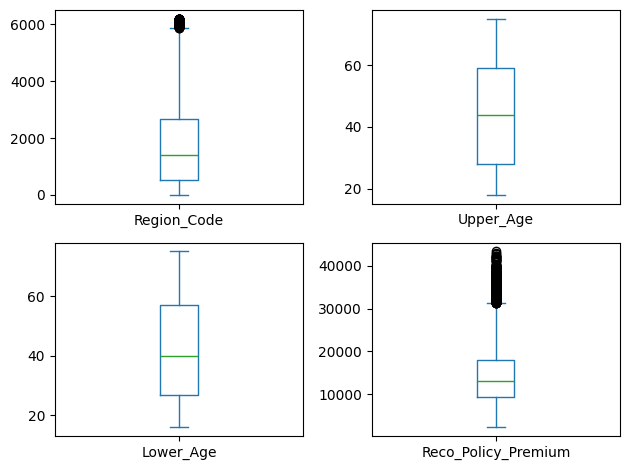

In [ ]:
continous_num_columns = ['Region_Code', 'Upper_Age', 'Lower_Age', 'Reco_Policy_Premium']

for i in range(0,4):
  plt.subplot(2,2,i+1)
  df1[continous_num_columns[i]].plot.box()

plt.tight_layout()
plt.show()

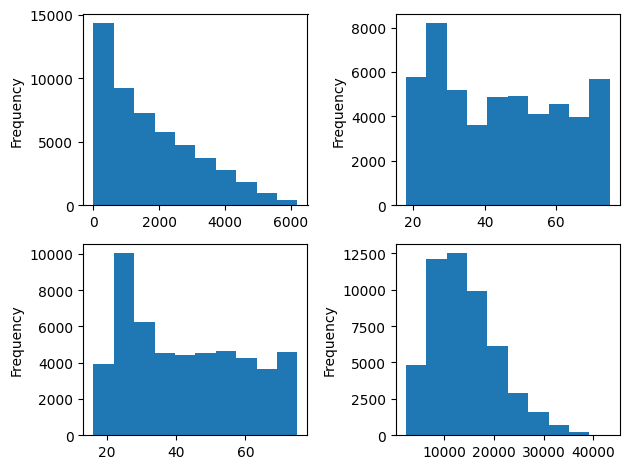

In [ ]:
continous_num_columns = ['Region_Code', 'Upper_Age', 'Lower_Age', 'Reco_Policy_Premium']

for i in range(0,4):
  plt.subplot(2,2,i+1)
  df1[continous_num_columns[i]].plot.hist()

plt.tight_layout()
plt.show()

<Axes: >

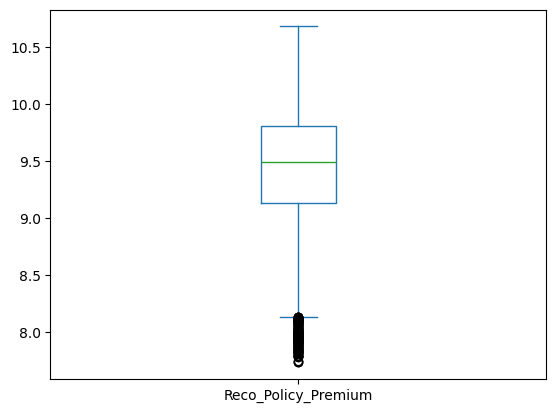

In [ ]:
np.log(df1['Reco_Policy_Premium']).plot.box()

<Axes: ylabel='Frequency'>

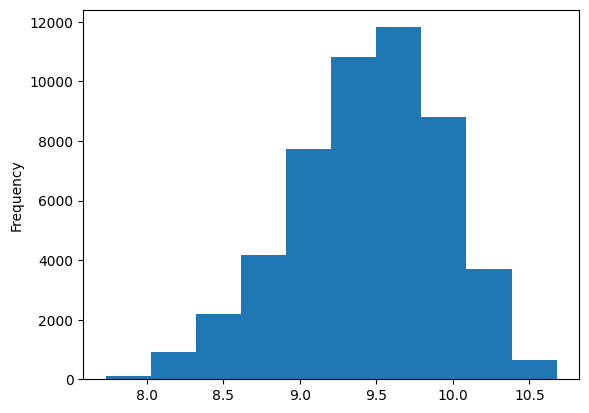

In [ ]:
np.log(df1['Reco_Policy_Premium']).plot.hist()

In [ ]:
df_num.head()

,Region_Code,Upper_Age,Lower_Age,Holding_Policy_Type,Reco_Policy_Cat,Reco_Policy_Premium,Response
0,3213,36,36,3.0,22,11628.0,0
1,1117,75,22,3.0,22,30510.0,0
2,3732,32,32,1.0,19,7450.0,1
3,4378,52,48,3.0,19,17780.0,0
4,2190,44,44,1.0,16,10404.0,0


In [ ]:
df1.head()

,City_Code,Region_Code,Accomodation_Type,Reco_Insurance_Type,Upper_Age,Lower_Age,Is_Spouse,Health Indicator,Holding_Policy_Duration,Holding_Policy_Type,Reco_Policy_Cat,Reco_Policy_Premium,Response
0,C3,3213,Rented,Individual,36,36,No,X1,14+,3.0,22,11628.0,0
1,C5,1117,Owned,Joint,75,22,No,X2,NaN,3.0,22,30510.0,0
2,C5,3732,Owned,Individual,32,32,No,NaN,1.0,1.0,19,7450.0,1
3,C24,4378,Owned,Joint,52,48,No,X1,14+,3.0,19,17780.0,0
4,C8,2190,Rented,Individual,44,44,No,X2,3.0,1.0,16,10404.0,0


In [ ]:
df_cat = df1.select_dtypes(exclude = 'number')
df_cat.head()

,City_Code,Accomodation_Type,Reco_Insurance_Type,Is_Spouse,Health Indicator,Holding_Policy_Duration
0,C3,Rented,Individual,No,X1,14+
1,C5,Owned,Joint,No,X2,NaN
2,C5,Owned,Individual,No,NaN,1.0
3,C24,Owned,Joint,No,X1,14+
4,C8,Rented,Individual,No,X2,3.0


In [ ]:
df_cat.isna().sum()

,0
City_Code,0
Accomodation_Type,0
Reco_Insurance_Type,0
Is_Spouse,0
Health Indicator,11691
Holding_Policy_Duration,20251


In [ ]:
df1['Health Indicator'].value_counts()

,count
Health Indicator,
X1,13010
X2,10332
X3,6762
X4,5743
X5,1727
X6,1280
X7,196
X8,78
X9,63


In [ ]:
df1['Holding_Policy_Duration'].value_counts()

,count
Holding_Policy_Duration,
1.0,4499
14+,4335
2.0,4260
3.0,3586
4.0,2771
5.0,2362
6.0,1894
7.0,1645
8.0,1316


In [ ]:
pd.crosstab(df1['Accomodation_Type'] , df1['Health Indicator'])

Health Indicator,X1,X2,X3,X4,X5,X6,X7,X8,X9
Accomodation_Type,,,,,,,,,
Owned,6637,5992,3202,3625,1195,585,145,48,36
Rented,6373,4340,3560,2118,532,695,51,30,27


In [ ]:
pd.crosstab(df1['Reco_Insurance_Type'] , df1['Health Indicator'])

Health Indicator,X1,X2,X3,X4,X5,X6,X7,X8,X9
Reco_Insurance_Type,,,,,,,,,
Individual,10681,8039,5642,4358,1198,1038,133,57,48
Joint,2329,2293,1120,1385,529,242,63,21,15


In [ ]:
pd.crosstab(df1['Is_Spouse'] , df1['Health Indicator'])

Health Indicator,X1,X2,X3,X4,X5,X6,X7,X8,X9
Is_Spouse,,,,,,,,,
No,11202,8382,5956,4543,1243,1107,140,61,51
Yes,1808,1950,806,1200,484,173,56,17,12


In [ ]:
#df1['Health Indicator'] = df1['Health Indicator'].fillna(df1['Is_Spouse'].apply(lambda x : 'X2'  if x == 'Yes' else 'X1'))

df1['Health Indicator'] = df1['Health Indicator'].fillna('Unknown')

In [ ]:
df1.isna().sum()

,0
City_Code,0
Region_Code,0
Accomodation_Type,0
Reco_Insurance_Type,0
Upper_Age,0
Lower_Age,0
Is_Spouse,0
Health Indicator,0
Holding_Policy_Duration,20251
Holding_Policy_Type,0


In [ ]:
df_cat = df1.select_dtypes(exclude = 'number')
df_cat.head()

,City_Code,Accomodation_Type,Reco_Insurance_Type,Is_Spouse,Health Indicator,Holding_Policy_Duration
0,C3,Rented,Individual,No,X1,14+
1,C5,Owned,Joint,No,X2,NaN
2,C5,Owned,Individual,No,Unknown,1.0
3,C24,Owned,Joint,No,X1,14+
4,C8,Rented,Individual,No,X2,3.0


In [ ]:
pd.crosstab(df1['Is_Spouse'] , df1['Holding_Policy_Duration'])

Holding_Policy_Duration,1.0,10.0,11.0,12.0,13.0,14+,14.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
Is_Spouse,,,,,,,,,,,,,,,
No,3783,632,411,402,394,3326,365,3577,2965,2260,1932,1542,1327,1012,882
Yes,716,181,135,111,117,1009,101,683,621,511,430,352,318,304,232


In [ ]:
pd.crosstab(df1['Reco_Insurance_Type'] , df1['Holding_Policy_Duration'])

Holding_Policy_Duration,1.0,10.0,11.0,12.0,13.0,14+,14.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
Reco_Insurance_Type,,,,,,,,,,,,,,,
Individual,3615,585,384,374,368,3100,338,3418,2830,2148,1811,1476,1250,964,831
Joint,884,228,162,139,143,1235,128,842,756,623,551,418,395,352,283


In [ ]:
df1['Holding_Policy_Duration'] = df1['Holding_Policy_Duration'].fillna(df1['Reco_Insurance_Type'].apply(lambda x : 1 if x == 'Individual' else '14+'))

In [ ]:
df1.head()

,City_Code,Region_Code,Accomodation_Type,Reco_Insurance_Type,Upper_Age,Lower_Age,Is_Spouse,Health Indicator,Holding_Policy_Duration,Holding_Policy_Type,Reco_Policy_Cat,Reco_Policy_Premium,Response
0,C3,3213,Rented,Individual,36,36,No,X1,14+,3.0,22,11628.0,0
1,C5,1117,Owned,Joint,75,22,No,X2,14+,3.0,22,30510.0,0
2,C5,3732,Owned,Individual,32,32,No,Unknown,1.0,1.0,19,7450.0,1
3,C24,4378,Owned,Joint,52,48,No,X1,14+,3.0,19,17780.0,0
4,C8,2190,Rented,Individual,44,44,No,X2,3.0,1.0,16,10404.0,0


In [ ]:
df1['City_Code'].value_counts()

,count
City_Code,
C1,8973
C2,7747
C3,4889
C4,3671
C9,2185
C6,1950
C7,1910
C8,1806
C10,1611


In [ ]:
text = 'C31'
text[1:]

'31'

In [ ]:
df2 = df1.copy()

In [ ]:
df2['City_Code'] = df2['City_Code'].apply(lambda x : int(x[1:]))

In [ ]:
df2.dtypes

,0
City_Code,int64
Region_Code,int64
Accomodation_Type,object
Reco_Insurance_Type,object
Upper_Age,int64
Lower_Age,int64
Is_Spouse,object
Health Indicator,object
Holding_Policy_Duration,object
Holding_Policy_Type,float64


In [ ]:
print(df2['Accomodation_Type'].unique())
print(df2['Reco_Insurance_Type'].unique())
print(df2['Is_Spouse'].unique())
print(df2['Health Indicator'].unique())
print(df2['Holding_Policy_Duration'].unique())

['Rented' 'Owned']
['Individual' 'Joint']
['No' 'Yes']
['X1' 'X2' 'Unknown' 'X4' 'X3' 'X6' 'X5' 'X8' 'X7' 'X9']
['14+' '1.0' '3.0' '5.0' 1 '9.0' '14.0' '7.0' '2.0' '11.0' '10.0' '8.0'
 '6.0' '4.0' '13.0' '12.0']


In [ ]:
df2['Accomodation_Type'] = df2['Accomodation_Type'].map({'Rented':0, 'Owned':1})
df2['Reco_Insurance_Type'] = df2['Reco_Insurance_Type'].map({'Individual':0, 'Joint':1})
df2['Is_Spouse'] = df2['Is_Spouse'].map({'No':0, 'Yes':1})

In [ ]:
def fix_hpd(duration):
  try:
    return int(duration)
  except:
    return 15

In [ ]:
df2['Holding_Policy_Duration'] = df2['Holding_Policy_Duration'].apply(fix_hpd)

In [ ]:
df2.head()

,City_Code,Region_Code,Accomodation_Type,Reco_Insurance_Type,Upper_Age,Lower_Age,Is_Spouse,Health Indicator,Holding_Policy_Duration,Holding_Policy_Type,Reco_Policy_Cat,Reco_Policy_Premium,Response
0,3,3213,0,0,36,36,0,X1,15,3.0,22,11628.0,0
1,5,1117,1,1,75,22,0,X2,15,3.0,22,30510.0,0
2,5,3732,1,0,32,32,0,Unknown,15,1.0,19,7450.0,1
3,24,4378,1,1,52,48,0,X1,15,3.0,19,17780.0,0
4,8,2190,0,0,44,44,0,X2,15,1.0,16,10404.0,0


In [ ]:
X = df2.drop(columns = 'Response')
y = df['Response']

In [ ]:
y.value_counts()

,count
Response,
0,38673
1,12209


In [ ]:
Xt = pd.get_dummies(X, dtype = int)
Xt.head()

,City_Code,Region_Code,Accomodation_Type,Reco_Insurance_Type,Upper_Age,Lower_Age,Is_Spouse,Holding_Policy_Duration,Holding_Policy_Type,Reco_Policy_Cat,...,Health Indicator_Unknown,Health Indicator_X1,Health Indicator_X2,Health Indicator_X3,Health Indicator_X4,Health Indicator_X5,Health Indicator_X6,Health Indicator_X7,Health Indicator_X8,Health Indicator_X9
0,3,3213,0,0,36,36,0,15,3.0,22,...,0,1,0,0,0,0,0,0,0,0
1,5,1117,1,1,75,22,0,15,3.0,22,...,0,0,1,0,0,0,0,0,0,0
2,5,3732,1,0,32,32,0,15,1.0,19,...,1,0,0,0,0,0,0,0,0,0
3,24,4378,1,1,52,48,0,15,3.0,19,...,0,1,0,0,0,0,0,0,0,0
4,8,2190,0,0,44,44,0,15,1.0,16,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
from imblearn.over_sampling import SMOTE
ovs = SMOTE()

Xr,yr = ovs.fit_resample(Xt,y)

In [ ]:
yr.value_counts()

,count
Response,
0,38673
1,38673


In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(Xr,yr)

In [ ]:
from sklearn.linear_model import LogisticRegression
modelA = LogisticRegression()
modelA.fit(xtrain,ytrain)

LogisticRegression()

In [ ]:
print(modelA.score(xtrain,ytrain))

0.5909772621489768


In [ ]:
print(modelA.score(xtest,ytest))

0.5909913637068832


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(ytrain , modelA.predict(xtrain)))

              precision    recall  f1-score   support

           0       0.60      0.56      0.58     28946
           1       0.59      0.62      0.60     29063

    accuracy                           0.59     58009
   macro avg       0.59      0.59      0.59     58009
weighted avg       0.59      0.59      0.59     58009



In [ ]:
print(classification_report(ytest , modelA.predict(xtest)))

              precision    recall  f1-score   support

           0       0.60      0.56      0.58      9727
           1       0.58      0.62      0.60      9610

    accuracy                           0.59     19337
   macro avg       0.59      0.59      0.59     19337
weighted avg       0.59      0.59      0.59     19337

